In [1]:
!pip install -q requests python-dotenv tqdm


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# %%
import os
import json
import re
import time
import requests
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from dotenv import load_dotenv
import matplotlib.pyplot as plt


In [3]:
# %%
load_dotenv()

OR_API_KEY = os.getenv("OPENROUTER_API_KEY")

if not OR_API_KEY:
    raise Exception("❌ ERROR: OPENROUTER_API_KEY not found in .env")


In [4]:
# %%
OPENROUTER_MODEL = "meta-llama/llama-3.1-70b-instruct"


In [5]:
# %%
def call_llm_raw(prompt):
    url = "https://openrouter.ai/api/v1/chat/completions"

    headers = {
        "Authorization": f"Bearer {OR_API_KEY}",
        "Content-Type": "application/json"
    }

    body = {
        "model": OPENROUTER_MODEL,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "temperature": 0.0,
        "response_format": {"type": "json_object"}   # Force JSON
    }

    try:
        res = requests.post(url, headers=headers, json=body, timeout=60)
        data = res.json()
        return data["choices"][0]["message"]["content"]
    except Exception as e:
        return f"LLM Error: {e}"


In [6]:
# %%
def extract_json(text):
    try:
        return json.loads(text)
    except:
        return None


def is_valid_json(obj):
    if not isinstance(obj, dict): return False
    if "predicted_stars" not in obj: return False
    if "explanation" not in obj: return False

    try:
        s = int(obj["predicted_stars"])
        return 1 <= s <= 5
    except:
        return False


In [7]:
# %%
df = pd.read_csv("yelp.csv")

df = df.sample(200).reset_index(drop=True)  # fewer calls, still strong

df.head()


,business_id,date,review_id,stars,text,type,user_id,cool,useful,funny
0,A5jJS6lNQbJXjPzBkTnjNQ,2012-07-22,lewi0wJfkpdXkrQWdEY8Vg,5,Good food at a good price.,review,s1uMhsAjfU_IwOMUEaOuSg,0,0,0
1,LjjcWJtE9RKdUMd25EsL5A,2012-09-28,a_3K4EHta-2rsTk9srS3GA,5,After shopping all over town and visiting ever...,review,4Zk_SPnvJ8Ybdjwo4BOJ5A,0,0,1
2,7SO_rX1F6rQEl-5s3wZxgQ,2011-08-22,u86A4P5mPKIQNir48-TUlQ,4,"Oooooh, I liked it, very much so! Just sad th...",review,Lmgv46LyI1PlLs0KNIfYFQ,0,0,0
3,r7Ge8_c5Y2TXthb4CSjzaA,2009-10-30,Uiif0BxCoTm0Ztr8ONNWkw,1,I don't expect much when grabbing lunch at a m...,review,GnZWh25MyJD1d5FMKl3QmA,3,3,1
4,GVg4GHHRblwY1MFlV1ubAw,2012-09-24,LI1em8rbUaQvCc2vj7Sp-A,4,My daughter has been attending Gold Medal Swim...,review,64YY0h0ZAR2nbzxbx0IwJg,2,3,2


In [8]:
# %%
PROMPT_A = """
You MUST respond ONLY with valid JSON. Do not include anything outside JSON.

Classify this review into a star rating (1–5):

Review:
"{review}"

Return:

{{
  "predicted_stars": 3,
  "explanation": "short explanation"
}}
"""


In [9]:
PROMPT_B = """
You are a strict JSON generator. Respond ONLY with JSON.

Examples:
"Great food and friendly staff." -> {{ "predicted_stars": 5, "explanation": "positive" }}
"Food was cold and staff rude." -> {{ "predicted_stars": 1, "explanation": "negative" }}
"Okay but nothing special." -> {{ "predicted_stars": 3, "explanation": "neutral" }}

Now classify:
"{review}"

Return:

{{
  "predicted_stars": 3,
  "explanation": "short explanation"
}}
"""


In [10]:
PROMPT_C = """
Return ONLY JSON. No explanation outside JSON.

Rubric:
5 = very positive
4 = mostly positive
3 = mixed
2 = mostly negative
1 = very negative

Review:
"{review}"

Return ONLY:

{{
  "predicted_stars": 3,
  "explanation": "short explanation"
}}
"""


In [11]:
# %%
def classify_review(prompt_template, review):
    prompt = prompt_template.format(review=review)

    raw = call_llm_raw(prompt)
    parsed = extract_json(raw)

    pred = None
    valid = False

    if parsed and is_valid_json(parsed):
        pred = int(parsed["predicted_stars"])
        valid = True

    return {
        "raw": raw,
        "parsed": parsed,
        "pred": pred,
        "valid_json": valid
    }


In [12]:
# %%
PROMPTS = {"A": PROMPT_A, "B": PROMPT_B, "C": PROMPT_C}
results = {k: [] for k in PROMPTS}

for i, row in tqdm(df.iterrows(), total=len(df)):
    review = row["text"]
    actual = int(row["stars"])

    for key, template in PROMPTS.items():
        out = classify_review(template, review)

        results[key].append({       
            "actual": actual,
            "pred": out["pred"],
            "valid_json": out["valid_json"],
            "raw": out["raw"]
        })


  0%|          | 0/200 [00:00<?, ?it/s]

In [13]:
# %%
def compute_metrics(entries):
    total = len(entries)
    accuracy = sum(1 for r in entries if r["pred"] == r["actual"]) / total
    json_validity = sum(1 for r in entries if r["valid_json"]) / total
    return accuracy, json_validity

metrics = {}

for k, v in results.items():
    acc, jv = compute_metrics(v)
    metrics[k] = {"accuracy": acc, "json_validity": jv}

pd.DataFrame(metrics)


,A,B,C
accuracy,0.59,0.615,0.625
json_validity,0.91,0.915,0.940


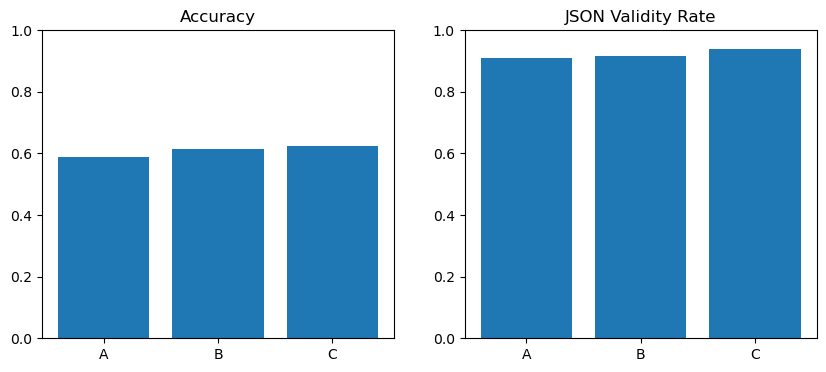

In [15]:
# %%
df_metrics = pd.DataFrame(metrics).T

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(df_metrics.index, df_metrics["accuracy"])
plt.ylim(0,1)
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.bar(df_metrics.index, df_metrics["json_validity"])
plt.ylim(0,1)
plt.title("JSON Validity Rate")

plt.show()


In [14]:
# %%
import os

os.makedirs("task1_outputs", exist_ok=True)

with open("task1_outputs/results.json", "w") as f:
    json.dump(results, f, indent=2)

pd.DataFrame(metrics).to_csv("task1_outputs/summary.csv")

print("Saved successfully!")


Saved successfully!
